# 03 — CNN (ResNet18, two-phase fine-tuning)

ImageNet-pretrained ResNet18, fine-tuned in two phases (phase 1: head only; phase 2:
last two residual blocks + head) at 128×128. Outputs are written to `results/cnn/`.
*Requires `01_eda.ipynb` to have produced `results/eda/dataset_stats.json`.*

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
# Make the project root importable whether run from notebooks/ or the project root.
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "src")) else os.path.dirname(cwd)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from src.dataset import PROJECT_ROOT
from src.evaluate import seed_everything
from IPython.display import Image, display, Markdown
seed_everything(42)

import torch
from src.dataset import CLASSES, RESNET_SIZE, RESNET_BATCH, NUM_WORKERS, make_loaders
from src.cnn import (build_resnet18, set_phase1_trainable, set_phase2_trainable,
                     train_two_phase, predict, extract_resnet_features)
from src.evaluate import (compute_metrics, save_confusion_matrix, count_params,
                          file_size_mb, measure_latency_ms, save_json, plot_training_curves)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
CNN_DIR = os.path.join(PROJECT_ROOT, "results", "cnn")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(CNN_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
with open(os.path.join(PROJECT_ROOT, "results", "eda", "dataset_stats.json")) as f:
    stats = json.load(f)
mean, std = stats["pixel_mean"], stats["pixel_std"]
print(f"Device: {device} | AMP: {use_amp} | mean={mean:.4f} std={std:.4f}")

Device: cuda | AMP: True | mean=0.0295 std=0.0346


**What this cell does**
- Imports PyTorch and the project's CNN helpers (`build_resnet18`, the two-phase trainer, the predict and feature functions).
- Picks the device (GPU if available) and turns on AMP (mixed precision) for faster training.
- Reads `dataset_stats.json` made in notebook 01 to get the pixel `mean` and `std`.

**Why**
- The model must normalize its inputs with the **same** mean/std found during EDA. This is why notebook 01 has to run first.

**Output**
- Shows `Device: cuda`, `AMP: True`, and `mean=0.0295 std=0.0346` — confirming the GPU is used and the EDA stats loaded correctly.

## Data loaders (train/val/test)

In [2]:
train_loader, val_loader, test_loader, (train_ds, val_ds, test_ds) = make_loaders(
    RESNET_SIZE, RESNET_BATCH, NUM_WORKERS, mean=mean, std=std)
print(f"Train={len(train_ds)} Val={len(val_ds)} Test={len(test_ds)}")

Train=2334 Val=413 Test=2425


**What this cell does**
- Builds the train, validation, and test data loaders at 128×128 with batch size 64. The train loader also adds light augmentation (random flips and small rotations); val and test do not.

**Why**
- Loaders feed images to the model in batches. Augmentation only on the train set helps the model generalize without changing how we measure val/test.

**Output**
- `Train=2334 Val=413 Test=2425` — the same split sizes found in notebook 01.

## Two-phase fine-tuning (training)

In [3]:
model = build_resnet18(len(CLASSES)).to(device)
ckpt = os.path.join(MODELS_DIR, "resnet18_best.pth")
t0 = time.perf_counter()
history, phase_boundary = train_two_phase(
    model, train_loader, val_loader, device, ckpt,
    set_phase1_trainable, set_phase2_trainable,
    epochs_phase1=10, epochs_phase2=15, lr1=1e-3, lr2=1e-4, patience=7, use_amp=use_amp)
train_time = time.perf_counter() - t0
print(f"Training finished in {train_time:.1f}s")

[P1 01/10] lr=1.00e-03 train_loss=2.1305 val_loss=2.0990 train_acc=0.2099 val_acc=0.2397 best=0.2397 *


[P1 02/10] lr=1.00e-03 train_loss=1.7315 val_loss=1.7547 train_acc=0.3702 val_acc=0.3729 best=0.3729 *


[P1 03/10] lr=1.00e-03 train_loss=1.5743 val_loss=1.6564 train_acc=0.4306 val_acc=0.3826 best=0.3826 *


[P1 04/10] lr=1.00e-03 train_loss=1.4815 val_loss=1.5874 train_acc=0.4662 val_acc=0.4358 best=0.4358 *


[P1 05/10] lr=1.00e-03 train_loss=1.4182 val_loss=1.5513 train_acc=0.5013 val_acc=0.4407 best=0.4407 *


...

[P2 11/15] lr=2.50e-05 train_loss=0.1533 val_loss=0.2339 train_acc=0.9520 val_acc=0.9225 best=0.9225 *


[P2 12/15] lr=1.65e-05 train_loss=0.1611 val_loss=0.2353 train_acc=0.9443 val_acc=0.9249 best=0.9249 *


[P2 13/15] lr=9.55e-06 train_loss=0.1357 val_loss=0.2227 train_acc=0.9576 val_acc=0.9177 best=0.9249


[P2 14/15] lr=4.32e-06 train_loss=0.1370 val_loss=0.2271 train_acc=0.9619 val_acc=0.9177 best=0.9249


[P2 15/15] lr=1.09e-06 train_loss=0.1339 val_loss=0.2220 train_acc=0.9554 val_acc=0.9177 best=0.9249
Training finished in 156.1s


**What this cell does**
- Builds a ResNet18 that was already pretrained on ImageNet, then fine-tunes it in **two phases**:
  - **Phase 1 (10 epochs, lr 1e-3):** freeze the backbone, train only the new classification head.
  - **Phase 2 (15 epochs, lr 1e-4, cosine schedule):** unfreeze the last two blocks (`layer3`, `layer4`) plus the head.
- Keeps the best-on-validation weights in `models/resnet18_best.pth` and stops early if validation stops improving.

**Why**
- Freeze-then-unfreeze is a safe transfer-learning recipe. The pretrained low-level filters are kept, and only the deeper, more task-specific layers are re-trained for SAR — this avoids overfitting on a small dataset.

**Output**
- Phase 1 plateaus low (val accuracy only ~0.50) — a frozen ImageNet backbone is not enough for radar images.
- Phase 2 jumps fast and reaches **best val accuracy 0.9249** (epoch 12). Total training time ≈ **156 s**.

## Evaluate the best checkpoint on the test set

In [4]:
model.load_state_dict(torch.load(ckpt, map_location=device))
y_true, y_pred, probs = predict(model, test_loader, device, use_amp)
feats, _ = extract_resnet_features(model, test_loader, device, use_amp)
metrics = compute_metrics(y_true, y_pred, CLASSES)
total_params, _ = count_params(model)
set_phase2_trainable(model)
_, trainable_params = count_params(model)
latency = measure_latency_ms(model, test_ds, device)
model_size = file_size_mb(ckpt)
out = dict(metrics)
out.update({
    "model": "ResNet18", "feature_dim": 512, "train_time_sec": train_time,
    "inference_ms_per_image": latency, "model_size_mb": model_size,
    "total_params": total_params, "trainable_params": trainable_params,
    "phase_boundary": phase_boundary, "history": history,
    "best_val_acc": max(h["val_acc"] for h in history), "input_size": RESNET_SIZE,
})
save_json(out, os.path.join(CNN_DIR, "cnn_metrics.json"))
save_confusion_matrix(metrics["confusion_matrix"], CLASSES,
    f"ResNet18 - Acc {metrics['accuracy']*100:.1f}%", os.path.join(CNN_DIR, "cm_cnn.png"))
plot_training_curves(history, phase_boundary, "ResNet18 - Training Curves",
    os.path.join(CNN_DIR, "cnn_training_curves.png"))
np.savez(os.path.join(CNN_DIR, "cnn_test_outputs.npz"),
         y_true=y_true, y_pred=y_pred, probs=probs, feats=feats)
print(f"Accuracy {metrics['accuracy']*100:.2f}%  Macro-F1 {metrics['macro_f1']*100:.2f}%")

Accuracy 92.49%  Macro-F1 91.52%


**What this cell does**
- Loads the best checkpoint, predicts the whole test set, and pulls out 512-number features (for the t-SNE plot in notebook 05).
- Computes all metrics, counts the parameters, measures speed and file size.
- Saves the metrics JSON, the confusion matrix image, the training-curve image, and the raw test outputs (`.npz`).

**Why**
- We always report the **best-validation** model on the held-out test set, using the same metrics as the other notebooks so the comparison is fair.

**Output**
- **Test accuracy 92.49%**, **Macro-F1 91.52%** — clearly better than the SVM's 85.98% from notebook 02.

## Results

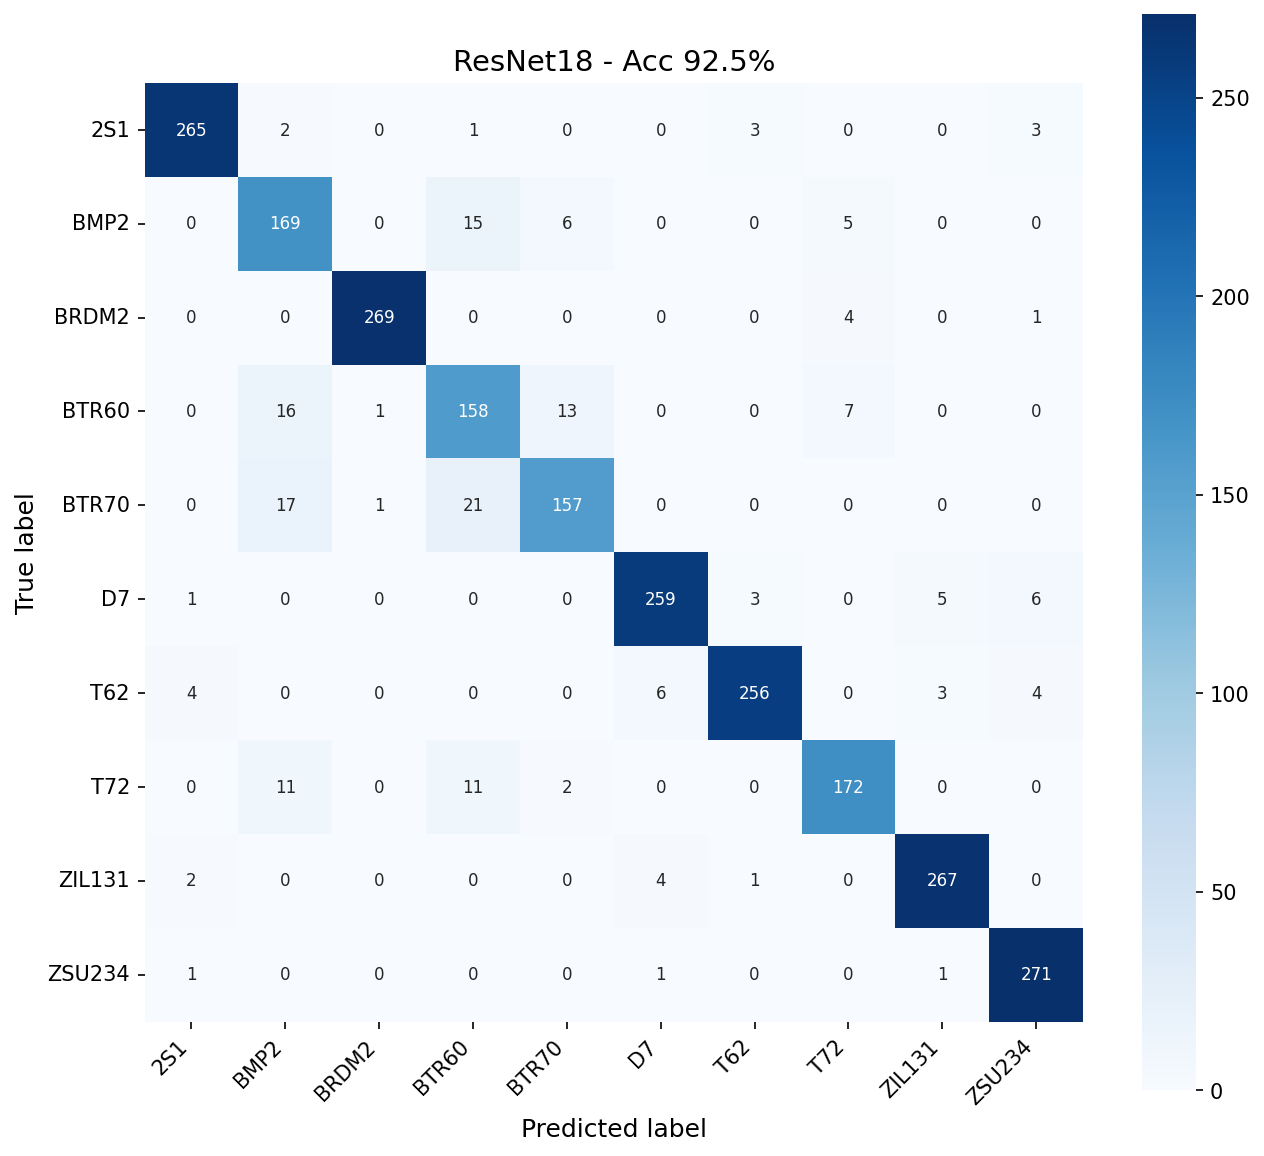

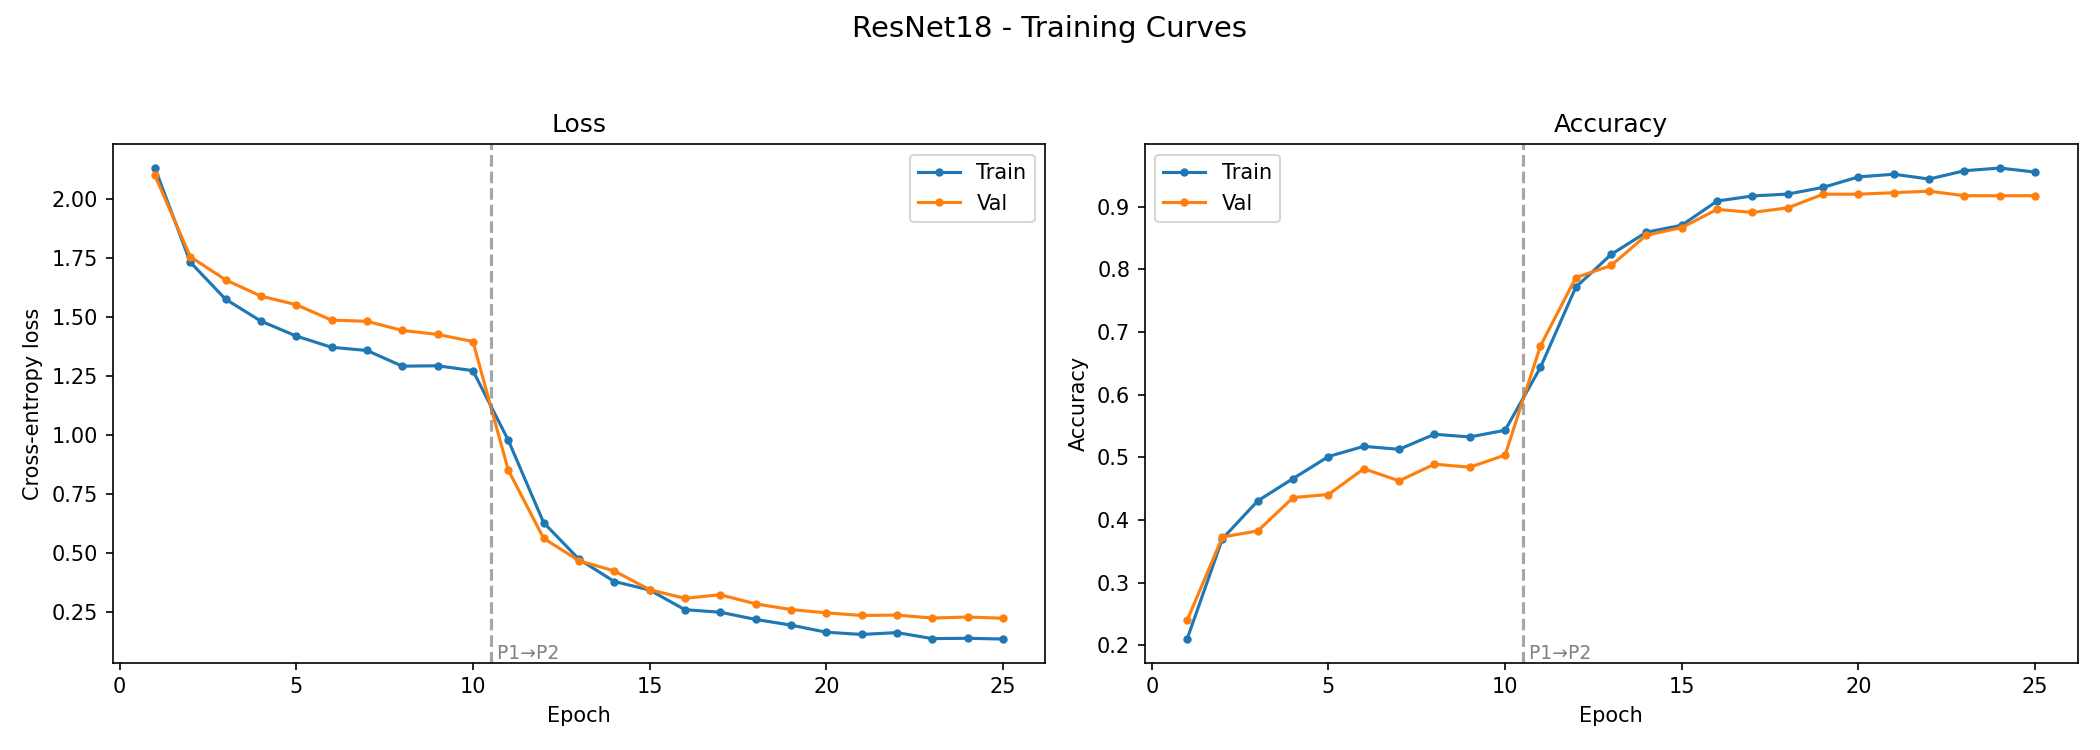

,ResNet18
Accuracy (%),92.49
Macro-F1 (%),91.52
Train time (s),156.10
Inference (ms/img),6.41
Model size (MB),42.70
Params (M),11.18


In [5]:
display(Image(filename=os.path.join(CNN_DIR, "cm_cnn.png")))
display(Image(filename=os.path.join(CNN_DIR, "cnn_training_curves.png")))
display(pd.DataFrame({"ResNet18": {
    "Accuracy (%)": round(metrics["accuracy"]*100, 2),
    "Macro-F1 (%)": round(metrics["macro_f1"]*100, 2),
    "Train time (s)": round(train_time, 1),
    "Inference (ms/img)": round(latency, 2),
    "Model size (MB)": round(model_size, 1),
    "Params (M)": round(total_params/1e6, 2),
}}))

**What this cell does**
- Shows the confusion matrix, the training curves, and a small table of the main numbers (accuracy, F1, train time, inference time, model size, parameter count).

**Why**
- A quick summary of the CNN result, in the same layout as the other notebooks.

**Output**
- The table confirms ResNet18 is the **smallest (≈42.7 MB)** and **fastest (≈6.4 ms/image)** model in the whole study, while still beating the SVM by about 6.5 accuracy points. It is the best balance of accuracy and speed.